# Telekom månedlige netværks-KPI'er: Databrugssøjler med ARPU- og kundeafgangslinjer (PROC GBARLINE)


## Resumé

Denne notebook bruger **PROC GBARLINE** til at kombinere et lodret søjlediagram over månedligt mobildataforbrug med overlejrede linjeplot af ARPU, kundeafgang og supportsager — det klassiske "to-akse" KPI-dashboard, en telekomanalytiker bygger for at se, om stigende forbrug rent faktisk omsættes til omsætning og fastholdelse. Den genererer syntetiske abonnentregistreringer direkte, og udnytter derefter BAR- og LINE-sætningerne med undergrupper, tilpassede højre akser, referencesymboler og forklaringer.

## Datakilder

**Datasæt: `telco_kpi`** — syntetiske abonnent-måned-registreringer (4 måneder x 3 abonnementstyper x 8 abonnenter = 96 rækker), genereret direkte med `call streaminit(20260531)`. Panelet holdes på 96 rækker, så det nemt passer inden for grænsen på 100 observationer i ulicenseret tilstand, hvilket efterlader hver måned og abonnementstype fuldt befolket.

| Variabel | Type | Beskrivelse |
|----------|------|-------------|
| `month`  | Char | Kalendermåned-etiket (jan–apr) |
| `plan`   | Char | Abonnementstype: Forudbetalt, Efterbetalt, Familie |
| `data_gb`| Num  | Månedligt mobildataforbrug, i GB (gammafordelt, med et mildt sæsonløft og langsom vækst) |
| `arpu`   | Num  | Gennemsnitlig omsætning pr. bruger, i USD (stiger med abonnementstype og hen over månederne) |
| `churn`  | Num  | Månedligt kundeafgangsflag (0/1, Bernoulli; højere tidligt i perioden og på lavere abonnementstyper) |
| `tickets`| Num  | Åbnede supportsager (Poisson-optælling) |

# Telekom månedlige netværks-KPI'er med PROC GBARLINE

Telekomoperatører lever og dør på en håndfuld månedlige KPI'er: hvor meget **data** abonnenterne forbruger, den **ARPU** (gennemsnitlige omsætning pr. bruger), som forbruget genererer, hvor mange kunder der **falder fra**, og den **supportsags**-belastning, der ligger bag det hele. Disse målinger lever på meget forskellige skalaer — gigabytes, dollars og små optællinger — så at plotte dem på en enkelt responsakse skjuler historien.

`PROC GBARLINE` er bygget netop til dette: den tegner et lodret **søjle**-diagram mod venstre akse og overlejrer et eller flere **linje**-plot mod en uafhængig højre akse. I denne notebook bygger vi et forbrug-vs-omsætning-dashboard og lægger derefter gradvist abonnement-niveau-undergrupper, en tilpasset højre akse og flerlinje-overlejringer ind.

## Trin 1 — Generér syntetiske abonnent-måned-data

DATA-trinnet nedenfor fremstiller et realistisk panel: 4 måneder (jan–apr) på tværs af 3 abonnementstyper (Forudbetalt, Efterbetalt, Familie) med 8 abonnenter hver, i alt 96 rækker. Vi seeder RNG'en med `call streaminit` for reproducerbarhed og trækker hver KPI fra en domænepassende fordeling:

- **Dataforbrug** fra en gammafordeling med et mildt sæsonløft og langsom vækst måned for måned.
- **ARPU** stigende med abonnementstype og hen over månederne, med normal støj.
- **Kundeafgang** som et Bernoulli-flag, der er højere tidligt i perioden og på billigere abonnementstyper.
- **Supportsager** som Poisson-optællinger, en smule tungere tidligt.

Der læses ingen eksterne filer — alt er selvstændigt, og panelet på 96 rækker holder sig inden for det ulicenserede loft på 100 observationer, så hver måned og abonnementstype gengives.

In [1]:
data telco_kpi;
    CALL streaminit(20260531);
    LÆNGDE month $3 plan $16;
    TABEL mname[4] $3 _temporary_
        ('Jan' 'Feb' 'Mar' 'Apr');
    GØR mi = 1 TIL 4;
        month = mname[mi];
        /* gentle seasonal lift and slow data growth */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        GØR plan_i = 1 TIL 3;
            HVIS plan_i = 1 SÅ plan = 'Forudbetalt';
            ELLERS HVIS plan_i = 2 SÅ plan = 'Efterbetalt';
            ELLERS plan = 'Familie';
            GØR rep = 1 TIL 8;
                /* monthly mobile data consumed (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* average revenue per user ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* monthly churn flag, higher early in year */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* support tickets opened */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                UDDATA;
            SLUT;
        SLUT;
    SLUT;
    FJERN mi plan_i rep season mname:;
KØR;



NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## Trin 2 — Kernedashboardet: forbrugssøjler + ARPU-linje

Dette er det kanoniske `GBARLINE`-mønster. `BAR`-sætningen viser det gennemsnitlige månedlige dataforbrug (`SUMVAR=data_gb TYPE=mean`), og en enkelt `LINE`-sætning overlejrer gennemsnitlig ARPU på højre akse (`STAT=mean TYPE=join`). Vi slår ODS Graphics til og giver diagrammet en totrins-titel. `COUTLINE=` og `WIDTH=` rydder op i søjlerne.

                                           Månedligt mobildataforbrug og ARPU                                           
                                           Syntetiske telekom-netværks-KPI'er                                           




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to Månedligt mobildataforbrug og ARPU.
NOTE: Option TITLE2 changed to Syntetiske telekom-netværks-KPI'er.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


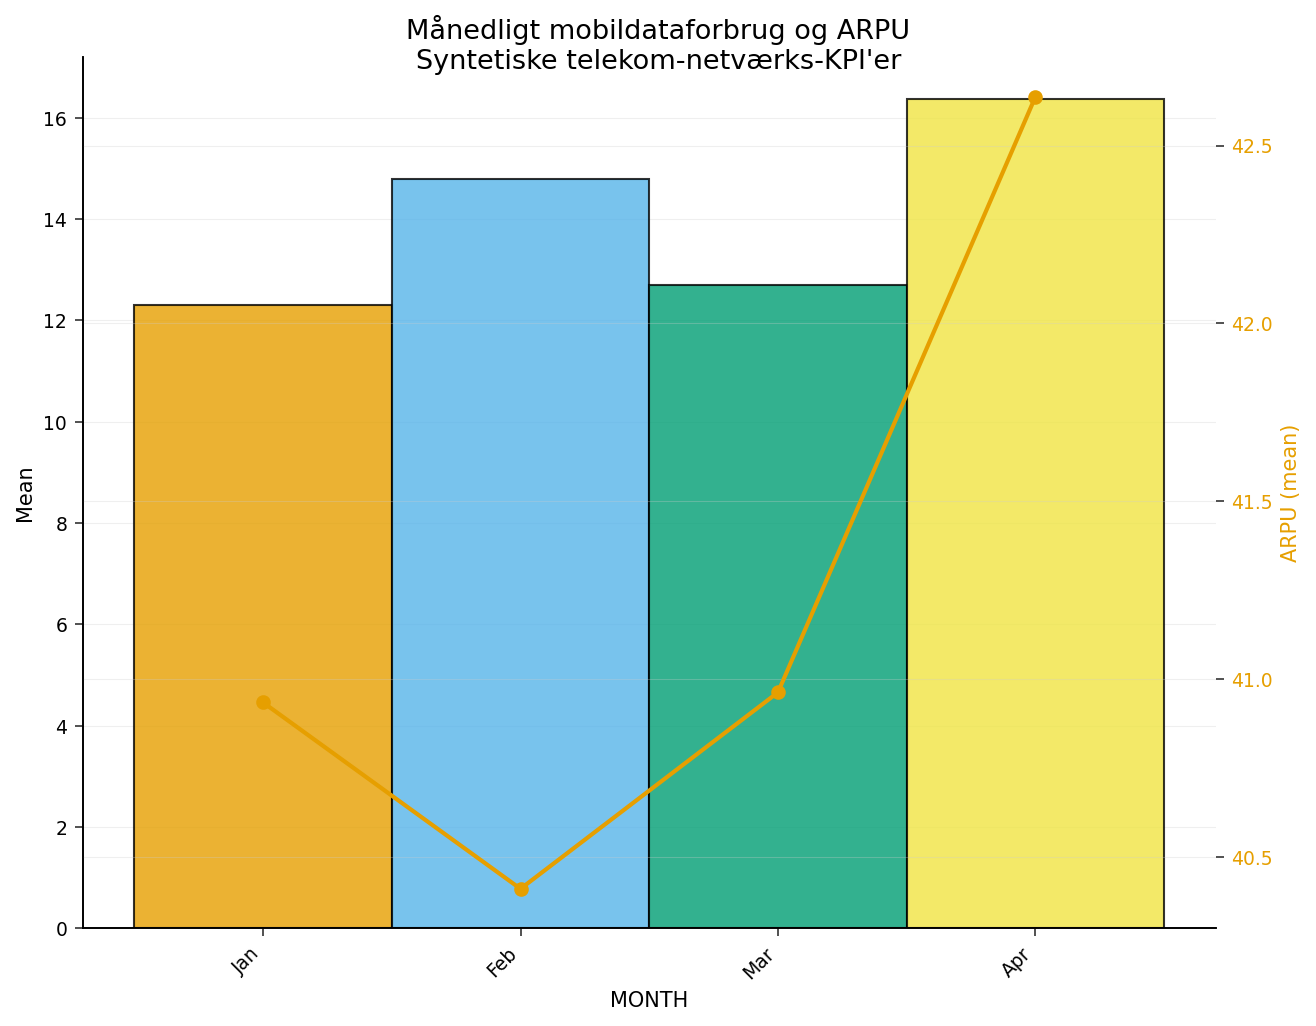

In [2]:
ODS GRAPHICS ON;
TITEL 'Månedligt mobildataforbrug og ARPU';
title2 "Syntetiske telekom-netværks-KPI'er";

PROCEDURE gbarline data=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
    MÆRKAT data_gb="Mobildataforbrug (GB)" arpu="ARPU ($)" month="Måned";
KØR;


## Trin 3 — Del forbruget op efter abonnement, overlejr kundeafgang

Ved at erstatte `TYPE=mean` med `TYPE=sum` og tilføje `SUBGROUP=plan` stables hver måneds søjle efter abonnementstype, så vi kan se, hvilket segment der driver den samlede volumen. Den overlejrede `LINE` plotter nu den månedlige **optælling** af kundeafgangshændelser som et nålediagram (`STAT=sum TYPE=needle`) — lodrette spidser, der naturligt læses som diskrete hændelsestællinger snarere end en glat tendens.

                                 Datamængde efter abonnement med månedligt kundeafgang                                  
                                           Syntetiske telekom-netværks-KPI'er                                           




NOTE: Option TITLE changed to Datamængde efter abonnement med månedligt kundeafgang.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


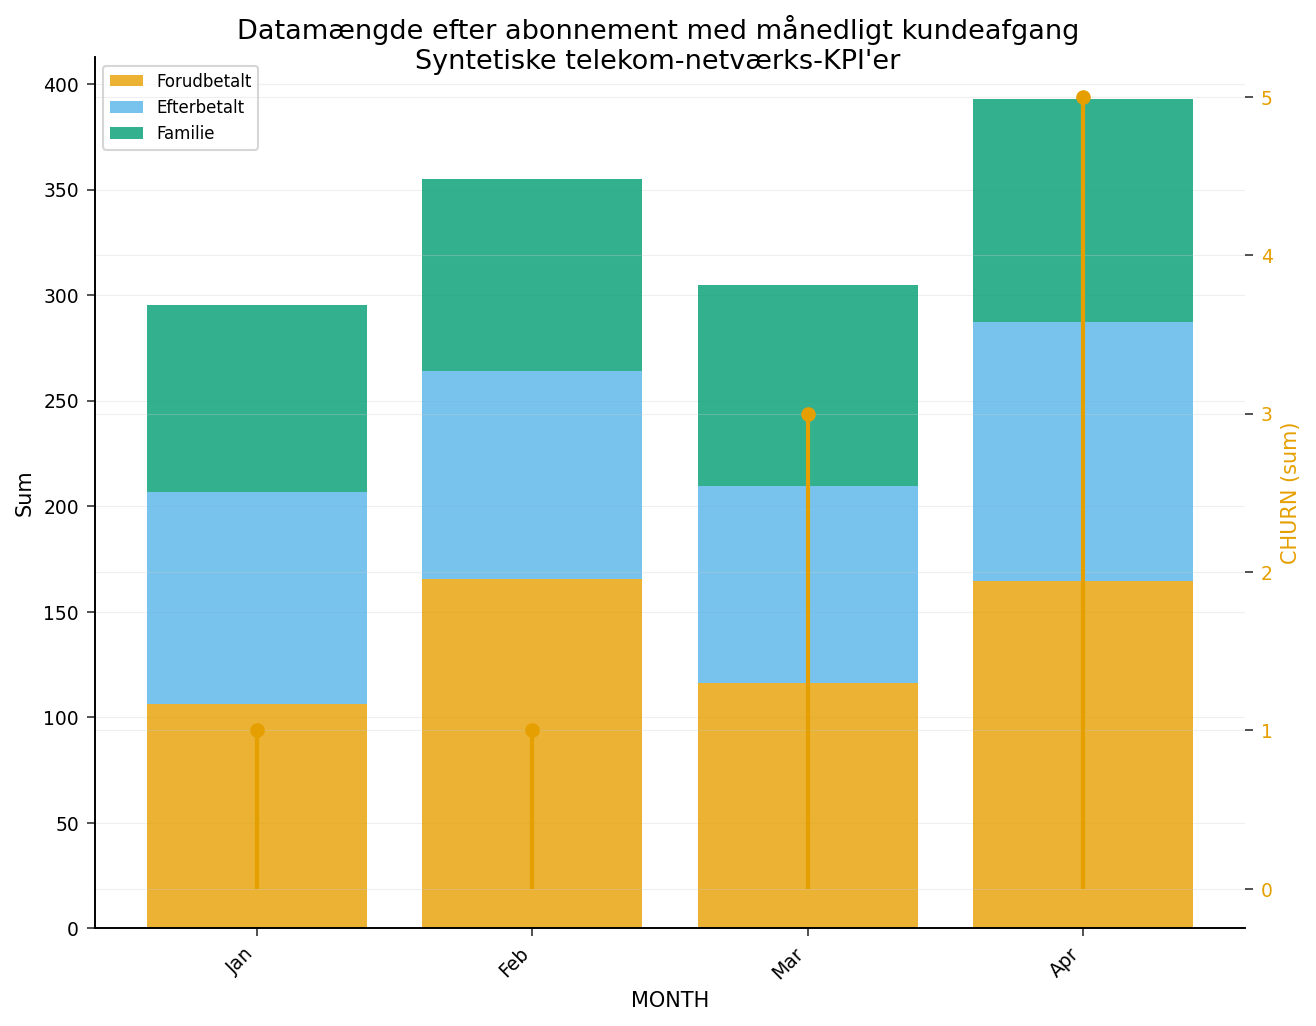

In [3]:
TITEL 'Datamængde efter abonnement med månedligt kundeafgang';

PROCEDURE gbarline data=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
    MÆRKAT data_gb="Mobildataforbrug (GB)" month="Måned" plan="Abonnement" churn="Kundeafgang";
KØR;


## Trin 4 — Styr højre akse og linjemarkøren

For et publiceringsklart diagram fastlåser vi plot-aksen (højre) til et fast interval med en `AXIS`-definition og navngiver den, og binder den derefter til linjen via `RAXIS=axis2`. En `SYMBOL`-definition giver ARPU-linjen en rød, prikket markør. Vi viser også søjletotalerne over hver søjle med `OUTSIDE=sum`.

                                 Samlet forbrug (søjler) vs. gennemsnitlig ARPU (linje)                                 
                                           Syntetiske telekom-netværks-KPI'er                                           




NOTE: Option TITLE changed to Samlet forbrug (søjler) vs. gennemsnitlig ARPU (linje).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


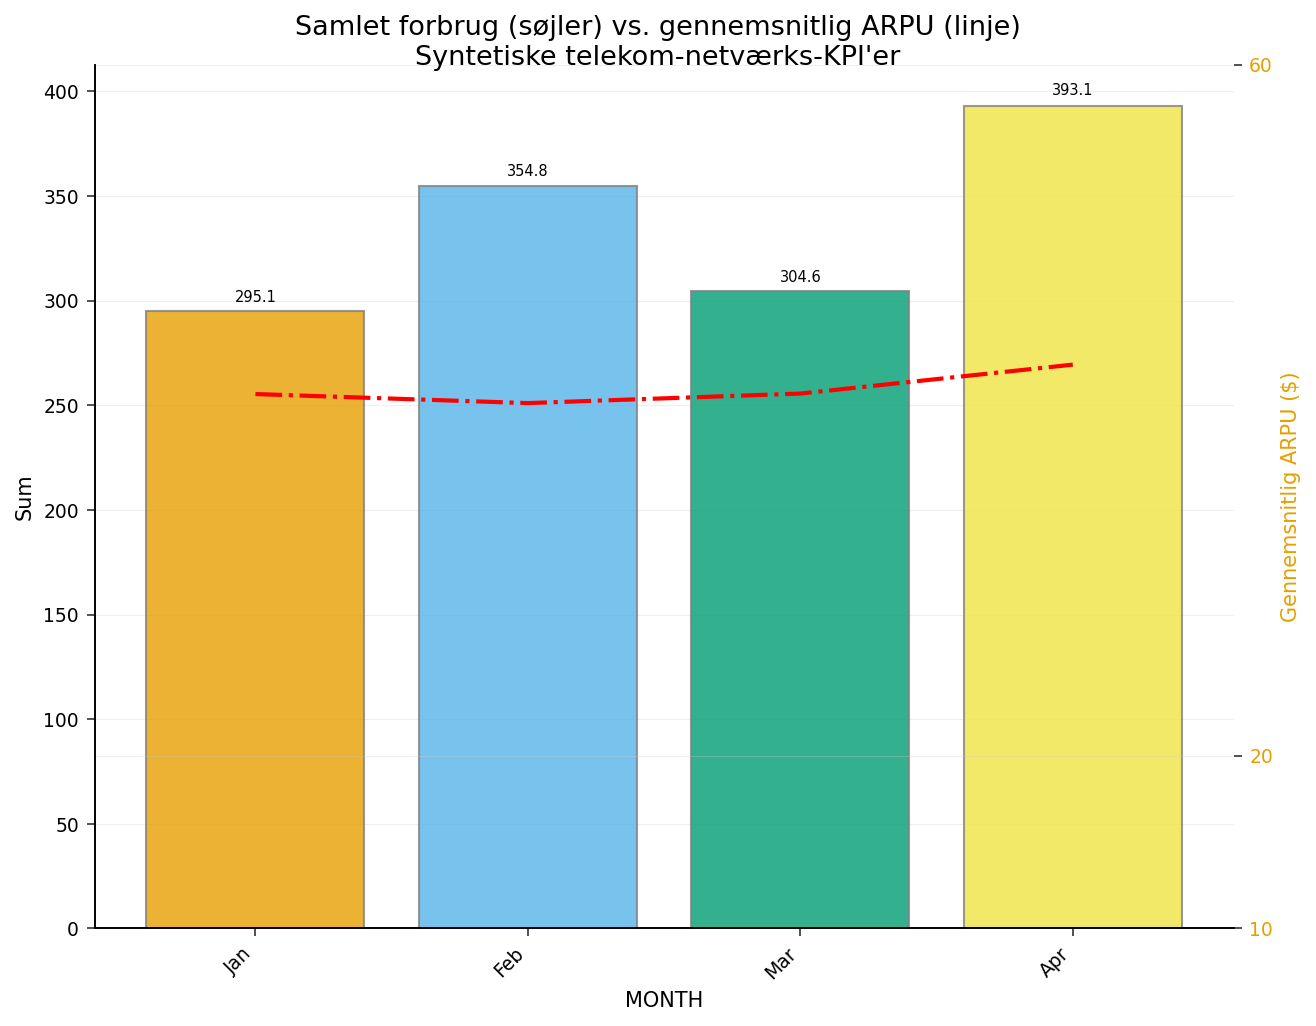

In [4]:
TITEL 'Samlet forbrug (søjler) vs. gennemsnitlig ARPU (linje)';

PROCEDURE gbarline data=telco_kpi;
    axis2 ORDER=(20 TIL 60 EFTER 10) MÆRKAT=('Gennemsnitlig ARPU ($)');
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
    MÆRKAT data_gb="Mobildataforbrug (GB)" month="Måned" arpu="ARPU ($)";
KØR;


## Trin 5 — Flere linjeoverlejringer med en tilpasset forklaring

`GBARLINE` accepterer mere end én `LINE`-sætning, så vi kan sammenligne to operationelle signaler mod forbrugssøjlerne på samme tid: gennemsnitlige supportsager (`type=join`) og samlet kundeafgang (`type=needle`). En `LEGEND`-definition placeret nederst dokumenterer abonnements-undergrupperne.

                                         Supportsager og kundeafgangstendenser                                          
                                           Syntetiske telekom-netværks-KPI'er                                           




NOTE: Option TITLE changed to Supportsager og kundeafgangstendenser.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


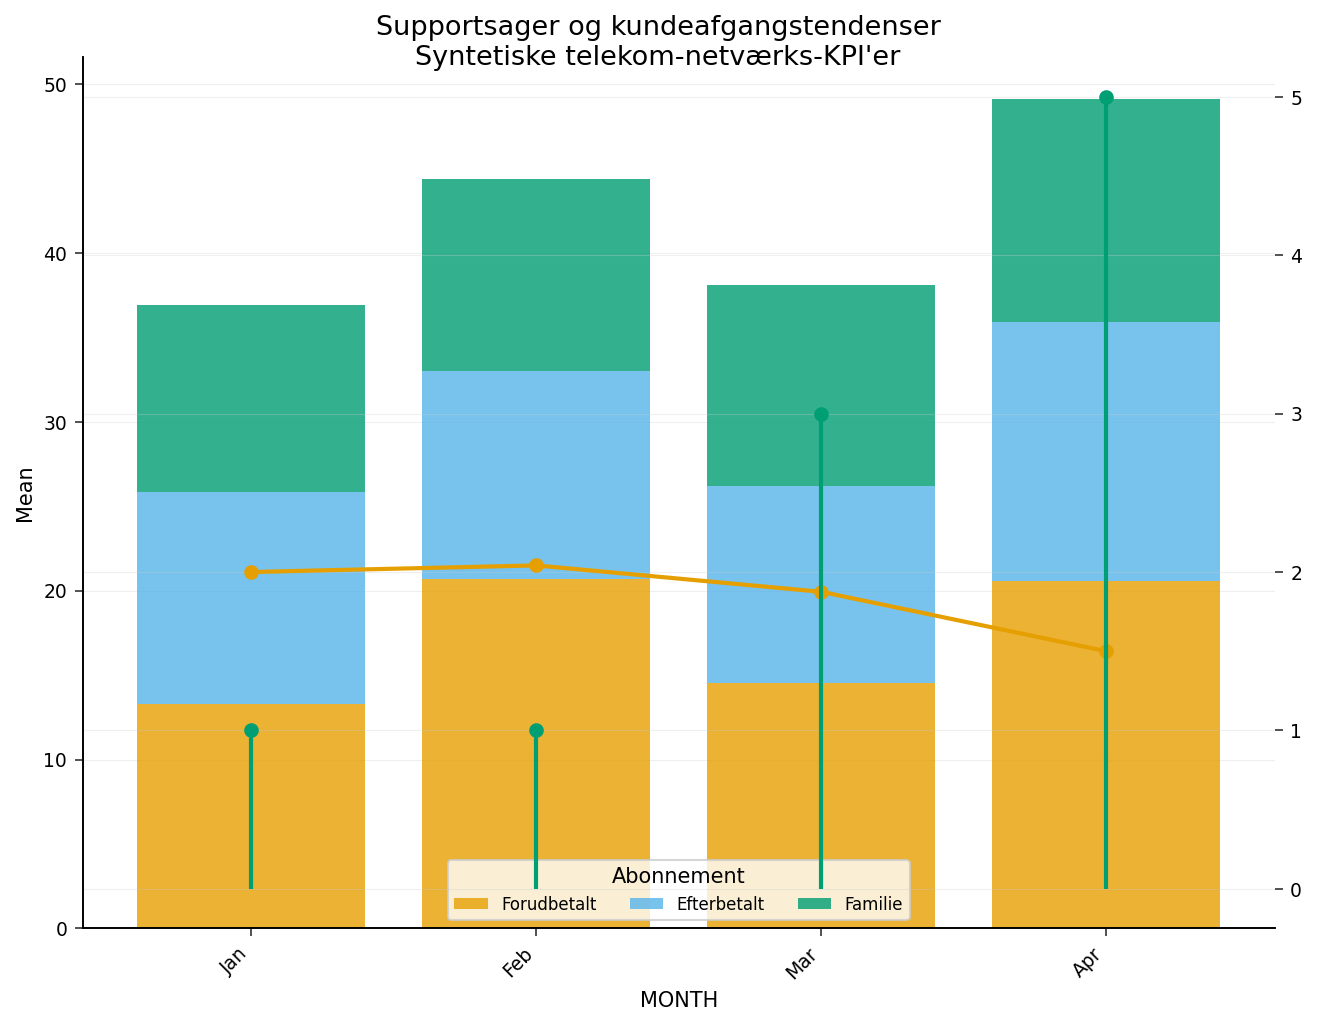

In [5]:
TITEL 'Supportsager og kundeafgangstendenser';

PROCEDURE gbarline data=telco_kpi;
    legend1 MÆRKAT=('Abonnement') position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
    MÆRKAT data_gb="Mobildataforbrug (GB)" month="Måned" plan="Abonnement" tickets="Supportsager" churn="Kundeafgang";
KØR;

ODS GRAPHICS OFF;


## Fortolkning af resultaterne

På tværs af jan–apr-vinduet fortæller dashboardet en sammenhængende telekomhistorie. **Dataforbruget** (søjlerne) er hakkende måned for måned, men følger en opadgående tendens og topper i **april** — gennemsnitligt forbrug stiger fra ca. 12.3 GB i januar til 16.4 GB i april (trin 2), og den samlede volumen fra 295 GB til 393 GB (`OUTSIDE=sum`-etiketterne i trin 4). **ARPU-linjen** dykker en smule i februar og stiger derefter til sit eget aprilhøjdepunkt nær \$42.6, så operatøren i stigende grad monetariserer det ekstra forbrug i stedet for at give det væk — højre akse i trin 4 er fastlåst til \$20–\$60 for at holde den bevægelse læsbar.

De abonnement-stablede visninger (trin 3 og 5) afslører den segmentspænding, der kendetegner udbydere med mange forudbetalte kunder. **Forudbetalt** (det orange bånd) bærer flest gigabytes samlet set — omkring 553 GB over de fire måneder mod 415 GB for Efterbetalt og 380 GB for Familie — men den tjener den **laveste** gennemsnitlige omsætning pr. bruger (omkring \$36, mod \$41 for Efterbetalt og \$47 for Familie). **Kundeafgangsnålene** bekræfter, hvor fastholdelsesrisikoen ligger: kundeafgangshændelser klumper sig sammen på abonnementstyperne Forudbetalt og Efterbetalt (4 hændelser hver over vinduet) og forbliver lettere på Familie (2), og de vokser hen imod april, efterhånden som abonnentbasen og forbruget udvides.

Trin 5 overlejrer den operationelle belastning oven på dette: gennemsnitlige **supportsager** kører en smule tungere tidligt i perioden og aftager hen mod april, mens kundeafgangsnålene topper senere — den slags signal, et fastholdelsesteam holder øje med. Operationelt peger aflæsningen på at koncentrere fastholdelsesindsatsen om **Forudbetalt**-abonnenter, som forbruger den hurtigst voksende andel af datavolumen, samtidig med at de genererer mindst omsætning og størst kundeafgang.

`PROC GBARLINE` er det rette værktøj her, netop fordi det holder søjlerne i gigabyte-skala og linjerne i dollar/optællings-skala på uafhængige akser, så hver KPI kan aflæses på sine egne præmisser, samtidig med at de deler den månedlige tidsakse.